In [1]:
import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns

#`df_personal`

## Data Wrangling

### Gathering Data

In [2]:
df_personal_noisy = pd.read_csv("fintrack_personal_noisy_dataset.csv")
df_personal_noisy.head()

,transaction_id,transaction_date,description,category,transaction_type,amount,payment_method
0,1.0,2024-05-17,Bonus,Gaji,Pemasukan,1912165.0,Kartu Debit
1,2.0,2024-05-18,Kirim uang keluarga,Transfer Teman/Keluarga,Pemasukan,201838.0,E-Wallet
2,3.0,2024-05-01,Ojek online,Transportasi,Pengeluaran,61356.0,Transfer Bank
3,4.0,2024-05-12,Perlengkapan rumah,Belanja Bulanan,Pengeluaran,237207.0,Kartu Kredit
4,5.0,2024-05-10,Service AC kos,Tempat Tinggal,Pengeluaran,51338.0,Kartu Debit


### Assessing Data

In [3]:
df_personal_noisy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3675 entries, 0 to 3674
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   transaction_id    3641 non-null   float64
 1   transaction_date  3637 non-null   object 
 2   description       3638 non-null   object 
 3   category          3643 non-null   object 
 4   transaction_type  3625 non-null   object 
 5   amount            3640 non-null   float64
 6   payment_method    3641 non-null   object 
dtypes: float64(2), object(5)
memory usage: 201.1+ KB


In [4]:
df_personal_noisy.isna().sum()

,0
transaction_id,34
transaction_date,38
description,37
category,32
transaction_type,50
amount,35
payment_method,34


In [5]:
print("Jumlah duplikasi: ", df_personal_noisy.duplicated().sum())

Jumlah duplikasi:  165


In [6]:
df_personal_noisy.describe(include='all')

,transaction_id,transaction_date,description,category,transaction_type,amount,payment_method
count,3641.000000,3637,3638,3643,3625,3.640000e+03,3641
unique,NaN,740,30,9,2,NaN,5
top,NaN,2026-04-21,Kirim uang keluarga,Transfer Teman/Keluarga,Pengeluaran,NaN,E-Wallet
freq,NaN,13,546,1053,2066,NaN,1045
mean,1747.411425,NaN,NaN,NaN,NaN,1.002760e+06,NaN
std,1006.383598,NaN,NaN,NaN,NaN,1.955592e+06,NaN
min,1.000000,NaN,NaN,NaN,NaN,-6.382512e+06,NaN
25%,878.000000,NaN,NaN,NaN,NaN,6.372400e+04,NaN
50%,1742.000000,NaN,NaN,NaN,NaN,1.897535e+05,NaN
75%,2616.000000,NaN,NaN,NaN,NaN,4.900448e+05,NaN


### Cleaning Data


In [7]:
# melihat data mana yang memiliki duplikat
df_personal_noisy[df_personal_noisy.duplicated()]


,transaction_id,transaction_date,description,category,transaction_type,amount,payment_method
3500,472.0,2026-04-19,Bayar kos,Tempat Tinggal,Pengeluaran,866381.0,E-Wallet
3501,108.0,2024-09-17,Tagihan internet,Pulsa & Internet,Pengeluaran,60461.0,Kartu Debit
3502,2467.0,2026-05-22,Gaji bulanan,Gaji,Pemasukan,6122610.0,Transfer Bank
3503,2262.0,2025-07-15,Bayar kos,Tempat Tinggal,Pengeluaran,992695.0,Transfer Bank
3504,3343.0,2024-12-23,Kirim uang keluarga,Transfer Teman/Keluarga,Pemasukan,114503.0,Transfer Bank
...,...,...,...,...,...,...,...
3670,1544.0,2024-08-15,Belanja kebutuhan pokok,Belanja Bulanan,Pengeluaran,487842.0,Kartu Kredit
3671,2913.0,2024-08-15,Iuran lingkungan,Tempat Tinggal,Pengeluaran,50047.0,Kartu Debit
3672,1050.0,2025-02-01,Transfer teman,Transfer Teman/Keluarga,Pemasukan,167549.0,Transfer Bank
3673,758.0,2025-07-17,Langganan streaming,Hiburan,Pengeluaran,30490.0,Kartu Kredit


In [8]:
# menghapus data duplikat
df_personal_noisy.drop_duplicates(inplace=True)
print("Jumlah duplikasi setelah cleaning: ", df_personal_noisy.duplicated().sum())

Jumlah duplikasi setelah cleaning:  0


In [9]:
# melihat data mana yang memiliki missing value
df_personal_noisy[df_personal_noisy.isna().any(axis=1)]

,transaction_id,transaction_date,description,category,transaction_type,amount,payment_method
7,8.0,2024-05-02,Pakaian baru,Belanja Bulanan,NaN,331997.0,Kartu Kredit
16,17.0,2024-06-19,Belanja dapur,Makanan & Minuman,NaN,314170.0,E-Wallet
25,26.0,NaN,Ojek online,Transportasi,Pengeluaran,23691.0,E-Wallet
28,29.0,2024-06-11,Langganan streaming,Hiburan,Pengeluaran,NaN,Kartu Debit
49,50.0,2024-08-12,Cloud storage,Pembayaran Langganan,Pengeluaran,50697.0,NaN
...,...,...,...,...,...,...,...
3461,3462.0,2025-11-28,Transfer teman,Transfer Teman/Keluarga,NaN,275391.0,E-Wallet
3462,3463.0,2024-07-06,NaN,Hiburan,Pengeluaran,476126.0,Kartu Kredit
3464,3465.0,2026-05-16,NaN,Gaji,Pemasukan,2205071.0,Transfer Bank
3489,3490.0,2026-04-09,Bonus,Gaji,NaN,1889244.0,Transfer Bank


In [10]:
# menghapus missing value pada kolom transaction_date
df_personal_noisy.dropna(subset=['transaction_date'], inplace=True)
print("Jumlah missing value pada kolom transaction_date setelah cleaning: ", df_personal_noisy['transaction_date'].isna().sum())

Jumlah missing value pada kolom transaction_date setelah cleaning:  0


In [11]:
# mengisi missing value pada kolom transaction_id dengan id unik baru
# ambil ID terbesar
max_id = int(df_personal_noisy['transaction_id'].max())

# hitung jumlah missing value
n_missing = df_personal_noisy['transaction_id'].isna().sum()

# buat ID baru unik
new_ids = range(max_id + 1, max_id + 1 + n_missing)

# isi missing value
df_personal_noisy.loc[
    df_personal_noisy['transaction_id'].isna(),
    'transaction_id'
] = list(new_ids)

# ubah tipe data menjadi integer
df_personal_noisy['transaction_id'] = df_personal_noisy['transaction_id'].astype(int)

In [12]:
print("Jumlah missing value pada kolom transaction_id setelah cleaning: ", df_personal_noisy['transaction_id'].isna().sum())

Jumlah missing value pada kolom transaction_id setelah cleaning:  0


In [13]:
# melihat kolom description yang memiliki missing value
df_personal_noisy[df_personal_noisy['description'].isna()]

,transaction_id,transaction_date,description,category,transaction_type,amount,payment_method
77,78,2024-08-03,NaN,Tempat Tinggal,Pengeluaran,946980.0,Transfer Bank
81,82,2024-08-07,NaN,Transportasi,Pengeluaran,48599.0,Tunai
310,311,2025-11-23,NaN,Pulsa & Internet,Pengeluaran,68623.0,Kartu Kredit
315,316,2025-11-07,NaN,Makanan & Minuman,Pengeluaran,330346.0,Kartu Debit
321,322,2025-11-28,NaN,Pembayaran Langganan,Pengeluaran,54616.0,Kartu Debit
437,438,2026-02-16,NaN,Transfer Teman/Keluarga,Pengeluaran,123696.0,Kartu Debit
649,650,2026-04-22,NaN,Makanan & Minuman,Pengeluaran,154261.0,Transfer Bank
658,659,2025-11-16,NaN,Transfer Teman/Keluarga,Pemasukan,68931.0,Kartu Debit
687,688,2024-10-23,NaN,Tempat Tinggal,Pengeluaran,50942.0,Tunai
780,781,2025-05-26,NaN,Belanja Bulanan,Pengeluaran,387501.0,Tunai


In [14]:
# mengisi missing value pada kolom description dengan nilai pada kolom category
df_personal_noisy['description'] = df_personal_noisy['description'].fillna(
    df_personal_noisy['category']
)
print("Jumlah missing value pada kolom description setelah cleaning: ", df_personal_noisy['description'].isna().sum())

Jumlah missing value pada kolom description setelah cleaning:  0


In [15]:
# melihat kolom transaction_type yang memiliki missing value
df_personal_noisy[df_personal_noisy['transaction_type'].isna()]

,transaction_id,transaction_date,description,category,transaction_type,amount,payment_method
7,8,2024-05-02,Pakaian baru,Belanja Bulanan,NaN,331997.0,Kartu Kredit
16,17,2024-06-19,Belanja dapur,Makanan & Minuman,NaN,314170.0,E-Wallet
87,88,2024-08-11,Paket data,Pulsa & Internet,NaN,118424.0,Transfer Bank
91,92,2024-08-12,Makan malam restoran,Makanan & Minuman,NaN,310376.0,E-Wallet
138,139,2025-02-17,Tagihan internet,Pulsa & Internet,NaN,73484.0,E-Wallet
213,214,2025-05-03,Liburan,Hiburan,NaN,364619.0,Kartu Kredit
219,220,2025-06-18,Bonus,Gaji,NaN,2382728.0,E-Wallet
266,267,2025-08-17,Bayar kos,Tempat Tinggal,NaN,936603.0,E-Wallet
552,553,2024-07-16,Transfer teman,Transfer Teman/Keluarga,NaN,286371.0,Transfer Bank
630,631,2024-10-25,Transfer teman,Transfer Teman/Keluarga,NaN,265807.0,E-Wallet


In [16]:
# mengisi transaction_type yang kosong dengan mapping kolom category
# membuat mapping dari data yang sudah ada
transaction_type_mapping = (
    df_personal_noisy
    .dropna(subset=['transaction_type'])
    .groupby('category')['transaction_type']
    .agg(lambda x: x.mode()[0])
    .to_dict()
)

# mengisi missing value pada kolom transaction_type berdasarkan category
mask = df_personal_noisy['transaction_type'].isna()

df_personal_noisy.loc[mask, 'transaction_type'] = (
    df_personal_noisy.loc[mask, 'category']
    .map(transaction_type_mapping)
)

print("Jumlah missing value pada kolom transaction_type setelah cleaning: ", df_personal_noisy['transaction_type'].isna().sum())

Jumlah missing value pada kolom transaction_type setelah cleaning:  1


In [17]:
# mengisi missing value pada kolom payment_method dengan nilai baru "Lainnya"
df_personal_noisy['payment_method'] = df_personal_noisy['payment_method'].fillna('Lainnya')
print("Jumlah missing value pada kolom payment_method setelah cleaning: ", df_personal_noisy['payment_method'].isna().sum())

Jumlah missing value pada kolom payment_method setelah cleaning:  0


In [18]:
# count value kolom payment_method
df_personal_noisy['payment_method'].value_counts()

,count
payment_method,
E-Wallet,990
Kartu Debit,977
Transfer Bank,959
Kartu Kredit,276
Tunai,239
Lainnya,32


In [19]:
# melihat nilai yang tidak sesuai pada kolom amount
df_personal_noisy[df_personal_noisy['amount'] < 0]

,transaction_id,transaction_date,description,category,transaction_type,amount,payment_method
13,14,2024-05-16,Kopi,Makanan & Minuman,Pengeluaran,-31632.0,Transfer Bank
190,191,2025-05-22,Gaji bulanan,Gaji,Pemasukan,-6269854.0,Kartu Debit
211,212,2025-05-09,Tiket KRL,Transportasi,Pengeluaran,-68134.0,Tunai
233,234,2025-07-24,Kopi,Makanan & Minuman,Pengeluaran,-68321.0,E-Wallet
335,336,2025-12-14,Taksi,Transportasi,Pengeluaran,-12511.0,Tunai
...,...,...,...,...,...,...,...
3137,3138,2025-11-09,Kirim uang keluarga,Transfer Teman/Keluarga,Pemasukan,-255982.0,Transfer Bank
3226,3227,2025-12-24,Tiket KRL,Transportasi,Pengeluaran,-35511.0,Tunai
3303,3304,2024-12-22,Transfer teman,Transfer Teman/Keluarga,Pemasukan,-166027.0,Kartu Debit
3488,3489,2025-03-09,Netflix,Pembayaran Langganan,Pengeluaran,-24077.0,E-Wallet


In [20]:
# ubah data negatif pada kolom amount menggunakan absolute
df_personal_noisy['amount'] = df_personal_noisy['amount'].abs()

In [21]:
# melihat missing value pada kolom amount
df_personal_noisy[df_personal_noisy['amount'].isna()]

,transaction_id,transaction_date,description,category,transaction_type,amount,payment_method
28,29,2024-06-11,Langganan streaming,Hiburan,Pengeluaran,NaN,Kartu Debit
103,104,2024-08-14,Iuran lingkungan,Tempat Tinggal,Pengeluaran,NaN,E-Wallet
115,116,2024-12-25,Transfer teman,Transfer Teman/Keluarga,Pemasukan,NaN,Kartu Debit
146,147,2025-03-19,Paket data,Pulsa & Internet,Pengeluaran,NaN,Kartu Debit
148,149,2025-03-23,Langganan streaming,Hiburan,Pengeluaran,NaN,Kartu Debit
155,156,2025-03-26,Bensin,Transportasi,Pengeluaran,NaN,Transfer Bank
299,300,2025-11-26,Bensin,Transportasi,Pengeluaran,NaN,E-Wallet
370,371,2026-01-12,Kirim uang keluarga,Transfer Teman/Keluarga,Pengeluaran,NaN,E-Wallet
480,481,2026-04-06,Tiket bioskop,Hiburan,Pengeluaran,NaN,Transfer Bank
633,634,2024-07-13,Kirim uang keluarga,Transfer Teman/Keluarga,Pengeluaran,NaN,Kartu Debit


In [22]:
# melakukan drop missing value pada kolom amount
df_personal_noisy.dropna(subset=['amount'], inplace=True)
print("Jumlah missing value pada kolom amount setelah cleaning: ", df_personal_noisy['amount'].isna().sum())

Jumlah missing value pada kolom amount setelah cleaning:  0


In [23]:
df_personal_noisy.isna().sum()

,0
transaction_id,0
transaction_date,0
description,0
category,30
transaction_type,1
amount,0
payment_method,0


In [24]:
# menyimpan dataset clean yang sudah dipreprocessing
df_personal_noisy.to_csv("fintrack_personal_clean_dataset.csv", index=False)

# `df_business`

## Data Wrangling

### Gathering Data

In [25]:
df_business_noisy = pd.read_csv("fintrack_business_noisy_dataset.csv")
df_business_noisy.head()

,transaction_id,transaction_date,description,category,transaction_type,amount,payment_method
0,1.0,2024-05-27,Pendapatan marketplace,Penjualan,Pemasukan,676749.0,QRIS
1,2.0,2024-05-15,Pendapatan proyek,Penjualan,Pemasukan,22241448.0,Tunai
2,3.0,2024-05-01,Investasi investor,Modal & Investasi,Pemasukan,85947193.0,Transfer Bank
3,NaN,2024-05-05,Penjualan produk,Penjualan,Pemasukan,1278397.0,Tunai
4,5.0,2024-05-06,Pendapatan proyek,Penjualan,Pemasukan,10420797.0,NaN


### Assessing Data

In [26]:
df_business_noisy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3150 entries, 0 to 3149
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   transaction_id    3122 non-null   float64
 1   transaction_date  3112 non-null   object 
 2   description       3115 non-null   object 
 3   category          3121 non-null   object 
 4   transaction_type  3119 non-null   object 
 5   amount            3120 non-null   float64
 6   payment_method    3115 non-null   object 
dtypes: float64(2), object(5)
memory usage: 172.4+ KB


In [27]:
df_business_noisy.isna().sum()

,0
transaction_id,28
transaction_date,38
description,35
category,29
transaction_type,31
amount,30
payment_method,35


In [28]:
print("Jumlah duplikasi: ", df_business_noisy.duplicated().sum())

Jumlah duplikasi:  130


In [29]:
df_business_noisy.describe(include='all')

,transaction_id,transaction_date,description,category,transaction_type,amount,payment_method
count,3122.000000,3112,3115,3121,3119,3.120000e+03,3115
unique,NaN,728,73,14,2,NaN,7
top,NaN,2024-10-13,Pelunasan invoice,Piutang,Pengeluaran,NaN,Transfer Bank
freq,NaN,13,126,458,1783,NaN,1478
mean,1499.712044,NaN,NaN,NaN,NaN,1.496105e+07,NaN
std,862.137717,NaN,NaN,NaN,NaN,3.232183e+07,NaN
min,1.000000,NaN,NaN,NaN,NaN,-1.924061e+08,NaN
25%,757.250000,NaN,NaN,NaN,NaN,1.267006e+06,NaN
50%,1497.500000,NaN,NaN,NaN,NaN,4.835078e+06,NaN
75%,2243.750000,NaN,NaN,NaN,NaN,1.558191e+07,NaN


### Cleaning Data

In [30]:
# melihat data mana yang memiliki duplikat
df_business_noisy[df_business_noisy.duplicated()]

,transaction_id,transaction_date,description,category,transaction_type,amount,payment_method
3000,2860.0,2025-02-15,Pembelian printer,Peralatan & Aset,Pengeluaran,8481027.0,Kartu Debit
3003,1488.0,2024-10-06,Pinjaman usaha,Modal & Investasi,Pemasukan,81392384.0,Transfer Bank
3004,934.0,2024-10-28,Bunga pinjaman,Utang & Cicilan,Pengeluaran,4086669.0,Transfer Bank
3005,2452.0,2024-12-05,Ongkos kirim,Transportasi & Logistik,Pengeluaran,1857700.0,Kartu Kredit
3007,388.0,2025-04-12,Administrasi legal,Pajak & Perizinan,Pengeluaran,4699406.0,Transfer Bank
...,...,...,...,...,...,...,...
3145,1381.0,2026-02-19,DP dari pelanggan,Piutang,Pemasukan,14831663.0,Transfer Bank
3146,1569.0,2024-08-24,Cicilan pelanggan,Piutang,NaN,4383044.0,Payment Gateway
3147,1680.0,2026-03-24,Cicilan pelanggan,Piutang,Pemasukan,2641134.0,Payment Gateway
3148,1555.0,2024-08-19,Biaya tarik tunai,Biaya Bank,Pengeluaran,33396.0,E-Wallet


In [31]:
# menghapus data duplikat
df_business_noisy.drop_duplicates(inplace=True)
print("Jumlah duplikasi setelah cleaning: ", df_business_noisy.duplicated().sum())

Jumlah duplikasi setelah cleaning:  0


In [32]:
# melihat data mana yang memiliki missing value
df_business_noisy[df_business_noisy.isna().any(axis=1)]

,transaction_id,transaction_date,description,category,transaction_type,amount,payment_method
3,NaN,2024-05-05,Penjualan produk,Penjualan,Pemasukan,1278397.0,Tunai
4,5.0,2024-05-06,Pendapatan proyek,Penjualan,Pemasukan,10420797.0,NaN
40,41.0,2024-07-20,NaN,Pajak & Perizinan,Pengeluaran,1590649.0,Transfer Bank
45,46.0,2024-08-29,Pelunasan invoice,Piutang,Pemasukan,NaN,Payment Gateway
53,54.0,2024-08-23,Pembelian bahan baku,Pembelian Stok,NaN,18207611.0,Kartu Kredit
...,...,...,...,...,...,...,...
2990,2991.0,2026-02-10,Biaya tak terduga,Lain-lain,NaN,NaN,Tunai
3129,1714.0,2024-11-09,Pendapatan grosir,Penjualan,Pemasukan,29146152.0,NaN
3130,1046.0,2026-02-07,Biaya tak terduga,Penjualan,Pengeluaran,NaN,Transfer Bank
3131,2081.0,NaN,Pelunasan invoice,Biaya Bank,Pemasukan,21743242.0,QRIS


In [33]:
# menghapus missing value pada kolom transaction_date
df_business_noisy.dropna(subset=['transaction_date'], inplace=True)
print("Jumlah missing value pada kolom transaction_date setelah cleaning: ", df_business_noisy['transaction_date'].isna().sum())

Jumlah missing value pada kolom transaction_date setelah cleaning:  0


In [34]:
# mengisi missing value pada kolom transaction_id dengan id unik baru
# ambil ID terbesar
max_id_business = int(df_business_noisy['transaction_id'].max())

# hitung jumlah missing value
n_missing_business = df_business_noisy['transaction_id'].isna().sum()

# buat ID baru unik
new_ids_business = range(max_id_business + 1, max_id_business + 1 + n_missing_business)

# isi missing value
df_business_noisy.loc[
    df_business_noisy['transaction_id'].isna(),
    'transaction_id'
] = list(new_ids_business)

# ubah tipe data menjadi integer
df_business_noisy['transaction_id'] = df_business_noisy['transaction_id'].astype(int)

In [35]:
print("Jumlah missing value pada kolom transaction_id setelah cleaning: ", df_business_noisy['transaction_id'].isna().sum())

Jumlah missing value pada kolom transaction_id setelah cleaning:  0


In [36]:
# melihat kolom description yang memiliki missing value
df_business_noisy[df_business_noisy['description'].isna()]

,transaction_id,transaction_date,description,category,transaction_type,amount,payment_method
40,41,2024-07-20,NaN,Pajak & Perizinan,Pengeluaran,1590649.0,Transfer Bank
264,265,2024-12-30,NaN,Pembelian Stok,Pengeluaran,6987164.0,E-Wallet
507,508,2025-09-10,NaN,Gaji & Karyawan,Pengeluaran,1333721.0,Transfer Bank
546,547,2025-11-18,NaN,Piutang,Pemasukan,2611325.0,Transfer Bank
644,645,2026-03-29,NaN,Marketing & Promosi,Pengeluaran,1045352.0,Kartu Debit
708,709,2026-04-24,NaN,Marketing & Promosi,Pengeluaran,11886091.0,E-Wallet
785,786,2024-07-26,NaN,Piutang,Pemasukan,21917323.0,QRIS
935,936,2026-01-27,NaN,Utang & Cicilan,Pengeluaran,2814545.0,Transfer Bank
990,991,2025-06-30,NaN,Modal & Investasi,Pemasukan,183650170.0,Transfer Bank
1068,1069,2026-05-18,NaN,Utang & Cicilan,Pengeluaran,30036289.0,Transfer Bank


In [37]:
# mengisi missing value pada kolom description dengan nilai pada kolom category
df_business_noisy['description'] = df_business_noisy['description'].fillna(
    df_business_noisy['category']
)
print("Jumlah missing value pada kolom description setelah cleaning: ", df_business_noisy['description'].isna().sum())

Jumlah missing value pada kolom description setelah cleaning:  0


In [38]:
# melihat kolom transaction_type yang memiliki missing value
df_business_noisy[df_business_noisy['transaction_type'].isna()]

,transaction_id,transaction_date,description,category,transaction_type,amount,payment_method
53,54,2024-08-23,Pembelian bahan baku,Pembelian Stok,NaN,18207611.0,Kartu Kredit
151,152,2024-10-21,Pembayaran utang supplier,Utang & Cicilan,NaN,7656559.0,Transfer Bank
235,236,2024-11-22,Pendapatan proyek,Penjualan,NaN,18476748.0,Payment Gateway
239,240,2024-11-26,Cicilan pelanggan,Piutang,NaN,393858.0,Transfer Bank
243,244,2024-11-20,Hosting website,Software & Langganan,NaN,661136.0,Kartu Kredit
356,357,2025-04-12,Pelunasan invoice,Piutang,NaN,-12058799.0,QRIS
641,642,2026-03-20,Air kantor,Operasional Kantor,NaN,958557.0,Kartu Kredit
821,822,2025-09-16,Sewa kantor,Operasional Kantor,NaN,8660391.0,Transfer Bank
1032,1033,2024-11-08,Pendapatan proyek,Penjualan,NaN,5201181.0,Transfer Bank
1259,1260,2024-11-27,Sewa kantor,Operasional Kantor,NaN,12127654.0,Transfer Bank


In [39]:
# mengisi transaction_type yang kosong dengan mapping kolom category
# membuat mapping dari data yang sudah ada
business_transaction_type_mapping = (
    df_business_noisy
    .dropna(subset=['transaction_type'])
    .groupby('category')['transaction_type']
    .agg(lambda x: x.mode()[0])
    .to_dict()
)

# mengisi missing value pada kolom transaction_type berdasarkan category
mask_business_ttype = df_business_noisy['transaction_type'].isna()

df_business_noisy.loc[mask_business_ttype, 'transaction_type'] = (
    df_business_noisy.loc[mask_business_ttype, 'category']
    .map(business_transaction_type_mapping)
)

print("Jumlah missing value pada kolom transaction_type setelah cleaning: ", df_business_noisy['transaction_type'].isna().sum())

Jumlah missing value pada kolom transaction_type setelah cleaning:  0


In [40]:
# mengisi missing value pada kolom payment_method dengan nilai baru "Lainnya"
df_business_noisy['payment_method'] = df_business_noisy['payment_method'].fillna('Lainnya')
print("Jumlah missing value pada kolom payment_method setelah cleaning: ", df_business_noisy['payment_method'].isna().sum())

Jumlah missing value pada kolom payment_method setelah cleaning:  0


In [41]:
# count value kolom payment_method
df_business_noisy['payment_method'].value_counts()

,count
payment_method,
Transfer Bank,1406
Kartu Debit,328
E-Wallet,264
QRIS,252
Tunai,239
Payment Gateway,238
Kartu Kredit,224
Lainnya,33


In [42]:
# melihat nilai yang tidak sesuai pada kolom amount (nilai negatif)
df_business_noisy[df_business_noisy['amount'] < 0]

,transaction_id,transaction_date,description,category,transaction_type,amount,payment_method
64,65,2024-08-06,Cicilan pinjaman usaha,Utang & Cicilan,Pengeluaran,-11980296.0,Transfer Bank
100,101,2024-09-02,Pelunasan invoice,Piutang,Pemasukan,-25903994.0,Transfer Bank
248,249,2024-11-13,Ongkos kirim,Transportasi & Logistik,Pengeluaran,-967254.0,Tunai
356,357,2025-04-12,Pelunasan invoice,Piutang,Pemasukan,-12058799.0,QRIS
612,613,2026-02-11,Pelunasan kredit usaha,Utang & Cicilan,Pengeluaran,-13232567.0,Transfer Bank
...,...,...,...,...,...,...,...
2989,2990,2024-12-09,Kurir,Transportasi & Logistik,Pengeluaran,-2865726.0,Kartu Debit
3002,1845,2025-03-07,Pembelian barang dagang,Pembelian Stok,Pengeluaran,-1729089.0,Kartu Kredit
3006,1540,2025-07-07,Pembelian barang dagang,Pembelian Stok,Pengeluaran,-3520990.0,Kartu Kredit
3009,2478,2024-10-22,Penjualan produk,Penjualan,Pemasukan,-1383435.0,E-Wallet


In [43]:
# ubah data negatif pada kolom amount menggunakan absolute
df_business_noisy['amount'] = df_business_noisy['amount'].abs()

In [44]:
# melihat missing value pada kolom amount
df_business_noisy[df_business_noisy['amount'].isna()]

,transaction_id,transaction_date,description,category,transaction_type,amount,payment_method
45,46,2024-08-29,Pelunasan invoice,Piutang,Pemasukan,NaN,Payment Gateway
61,62,2024-08-14,Langganan software akuntansi,Software & Langganan,Pengeluaran,NaN,Kartu Debit
110,111,2024-09-09,Diskon promosi,Marketing & Promosi,Pengeluaran,NaN,Transfer Bank
162,163,2024-10-16,Pelunasan kredit usaha,Utang & Cicilan,Pengeluaran,NaN,Transfer Bank
212,213,2024-10-14,Gaji karyawan,Gaji & Karyawan,Pengeluaran,NaN,Transfer Bank
573,574,2026-01-28,Biaya admin bank,Biaya Bank,Pengeluaran,NaN,Kartu Debit
897,898,2024-08-20,Pendapatan marketplace,Penjualan,Pemasukan,NaN,E-Wallet
913,914,2025-03-12,Cloud storage bisnis,Software & Langganan,Pengeluaran,NaN,Kartu Debit
956,957,2024-08-11,Bayar pajak usaha,Pajak & Perizinan,Pengeluaran,NaN,Transfer Bank
1045,1046,2026-02-07,Biaya tak terduga,Lain-lain,Pengeluaran,NaN,Transfer Bank


In [45]:
# mengisi missing value dengan median berdasarkan mapping kolom description
# membuat mapping description -> median amount
business_amount_mapping = (
    df_business_noisy
    .dropna(subset=['amount'])
    .groupby('description')['amount']
    .median()
    .to_dict()
)

# mencari missing value
mask_business_amount = df_business_noisy['amount'].isna()

# mengisi missing amount berdasarkan description
df_business_noisy.loc[mask_business_amount, 'amount'] = (
    df_business_noisy.loc[mask_business_amount, 'description']
    .map(business_amount_mapping)
)

print("Jumlah missing value pada kolom amount setelah cleaning: ", df_business_noisy['amount'].isna().sum())

Jumlah missing value pada kolom amount setelah cleaning:  0


In [46]:
# drop missing value
df_business_noisy.dropna(inplace=True)
df_business_noisy.isna().sum()

,0
transaction_id,0
transaction_date,0
description,0
category,0
transaction_type,0
amount,0
payment_method,0


In [47]:
# menyimpan dataset clean yang sudah dipreprocessing
df_business_noisy.to_csv("fintrack_business_clean_dataset.csv", index=False)

# Explaratory Data Analysis

Pertanyaan Bisnis
1. Apakah pengguna mampu menjaga pengeluaran pribadi tetap di bawah 80% dari total pemasukan setiap bulan selama 2 tahun terakhir?
2. Bagaimana kondisi arus kas bisnis selama 2 tahun terakhir, dan kategori biaya bisnis apa yang paling besar mengurangi keuntungan bulanan?

In [48]:
# memanggil data yang sudah dilakukan proses cleaning
data_personal = pd.read_csv("/content/fintrack_personal_clean_dataset.csv")
data_bisnis = pd.read_csv("/content/fintrack_business_clean_dataset.csv")

In [49]:
data_personal.describe(include='all')

,transaction_id,transaction_date,description,category,transaction_type,amount,payment_method
count,3442.000000,3442,3442,3412,3441,3.442000e+03,3442
unique,NaN,740,39,9,2,NaN,6
top,NaN,2025-11-23,Kirim uang keluarga,Transfer Teman/Keluarga,Pengeluaran,NaN,E-Wallet
freq,NaN,13,508,978,1953,NaN,982
mean,1769.314933,NaN,NaN,NaN,NaN,1.063467e+06,NaN
std,1018.105444,NaN,NaN,NaN,NaN,1.942511e+06,NaN
min,1.000000,NaN,NaN,NaN,NaN,1.020600e+04,NaN
25%,888.250000,NaN,NaN,NaN,NaN,6.785225e+04,NaN
50%,1767.500000,NaN,NaN,NaN,NaN,1.985590e+05,NaN
75%,2651.750000,NaN,NaN,NaN,NaN,5.707782e+05,NaN


In [50]:
data_bisnis.describe(include='all')

,transaction_id,transaction_date,description,category,transaction_type,amount,payment_method
count,2956.000000,2956,2956,2956,2956,2.956000e+03,2956
unique,NaN,728,83,14,2,NaN,8
top,NaN,2026-04-28,Investasi investor,Penjualan,Pengeluaran,NaN,Transfer Bank
freq,NaN,12,115,439,1683,NaN,1395
mean,1512.323410,NaN,NaN,NaN,NaN,1.577866e+07,NaN
std,870.776273,NaN,NaN,NaN,NaN,3.239745e+07,NaN
min,1.000000,NaN,NaN,NaN,NaN,4.258000e+03,NaN
25%,758.750000,NaN,NaN,NaN,NaN,1.383242e+06,NaN
50%,1514.500000,NaN,NaN,NaN,NaN,4.991944e+06,NaN
75%,2265.250000,NaN,NaN,NaN,NaN,1.596122e+07,NaN


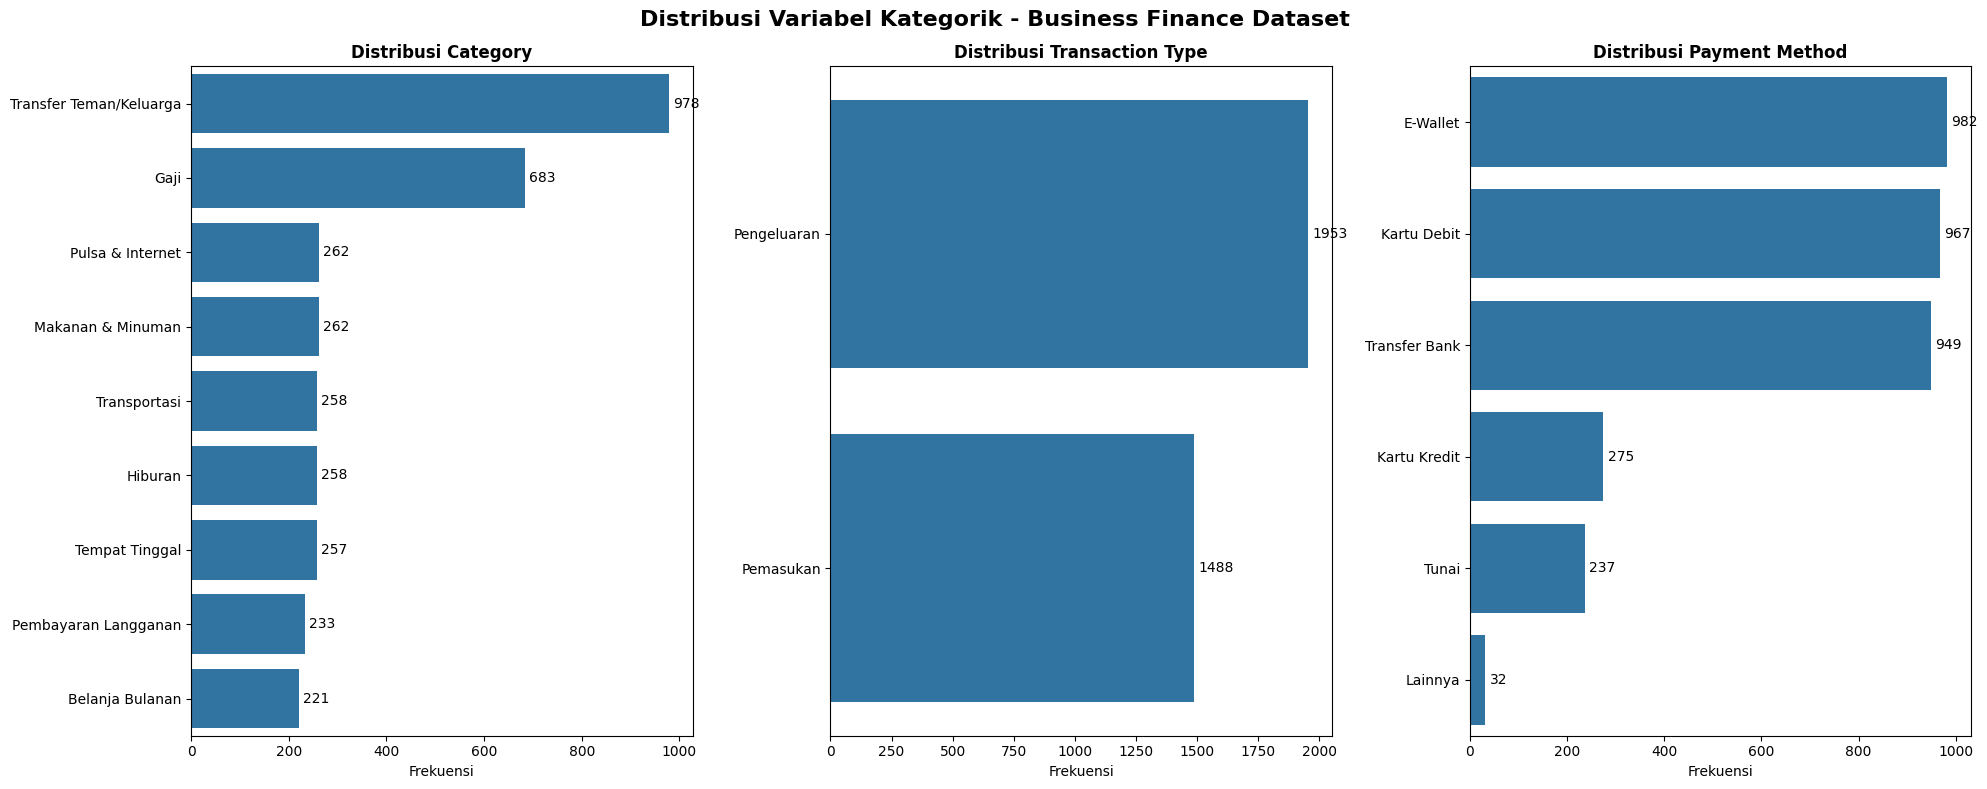

In [86]:
# membuat bar plot untuk melihat distribusi variabel kategorik datset personal
fig, axes = plt.subplots(1, 3, figsize=(20, 8))

cols = ['category', 'transaction_type', 'payment_method']
titles = [
    'Distribusi Category',
    'Distribusi Transaction Type',
    'Distribusi Payment Method'
]

for ax, col, title in zip(axes, cols, titles):

    order = data_personal[col].value_counts().index

    sns.countplot(
        data=data_personal,
        y=col,
        order=order,
        ax=ax
    )

    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Frekuensi')
    ax.set_ylabel('')

    # Menampilkan jumlah pada setiap bar
    for container in ax.containers:
        ax.bar_label(container, padding=3)

plt.suptitle(
    'Distribusi Variabel Kategorik - Business Finance Dataset',
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

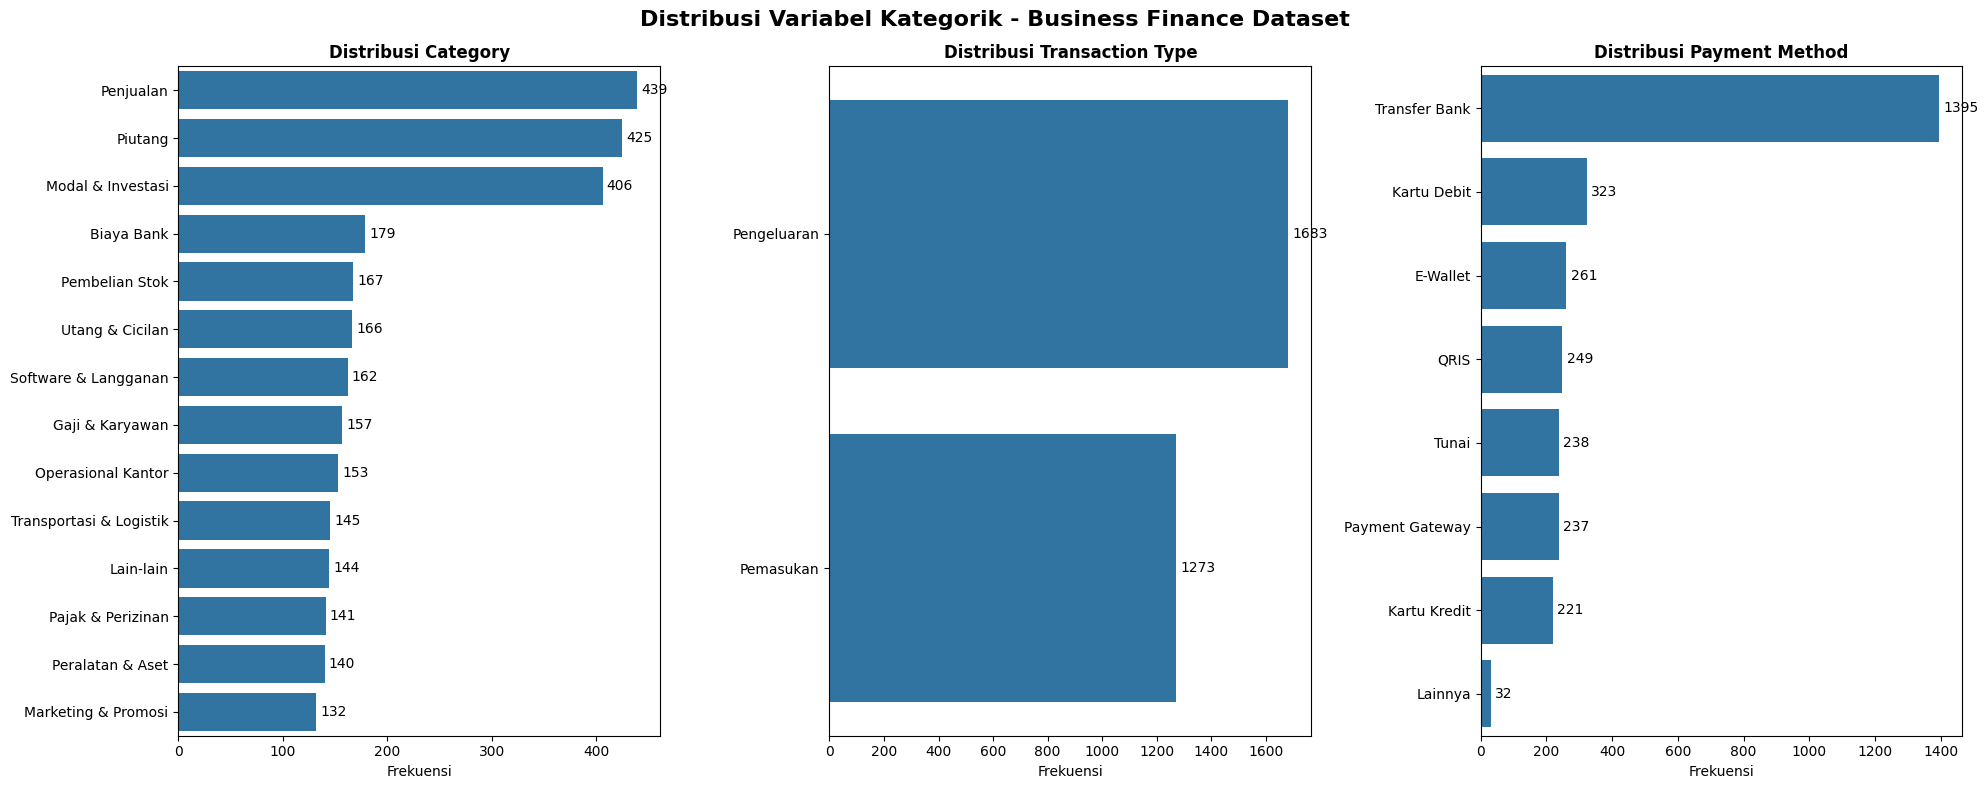

In [85]:
# membuat bar plot untuk melihat distribusi variabel kategorik datset business
fig, axes = plt.subplots(1, 3, figsize=(20, 8))

cols = ['category', 'transaction_type', 'payment_method']
titles = [
    'Distribusi Category',
    'Distribusi Transaction Type',
    'Distribusi Payment Method'
]

for ax, col, title in zip(axes, cols, titles):

    order = data_bisnis[col].value_counts().index

    sns.countplot(
        data=data_bisnis,
        y=col,
        order=order,
        ax=ax
    )

    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Frekuensi')
    ax.set_ylabel('')

    # Menampilkan jumlah pada setiap bar
    for container in ax.containers:
        ax.bar_label(container, padding=3)

plt.suptitle(
    'Distribusi Variabel Kategorik - Business Finance Dataset',
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

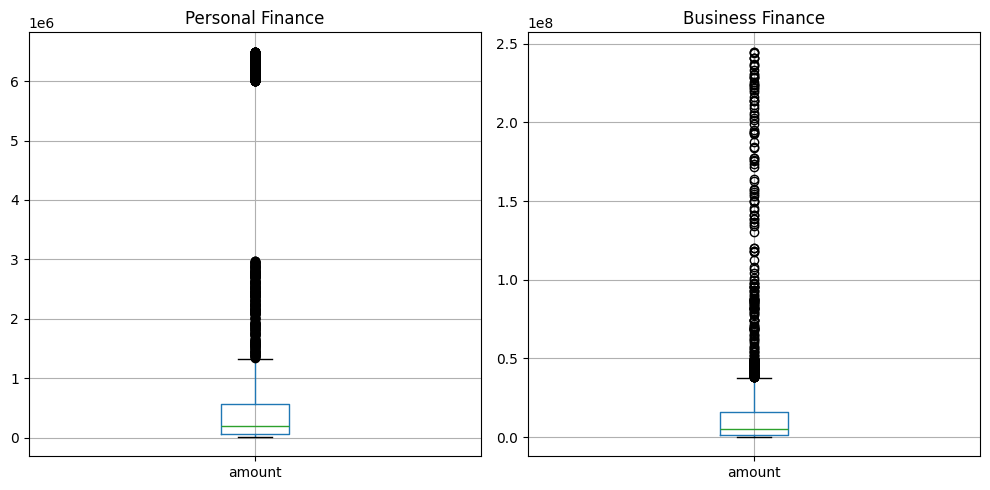

In [51]:
# membuat boxplot untuk kolom amount pada df_personal dan df_business
# membuat 2 boxplot dalam 1 output
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# boxplot personal
data_personal.boxplot(column='amount', ax=axes[0])
axes[0].set_title('Personal Finance')

# boxplot bisnis
data_bisnis.boxplot(column='amount', ax=axes[1])
axes[1].set_title('Business Finance')

plt.tight_layout()
plt.show()

In [52]:
# transformasi log
# transformasi log personal finance
data_personal['amount_log'] = np.log1p(
    data_personal['amount']
)

# transformasi log business finance
data_bisnis['amount_log'] = np.log1p(
    data_bisnis['amount']
)

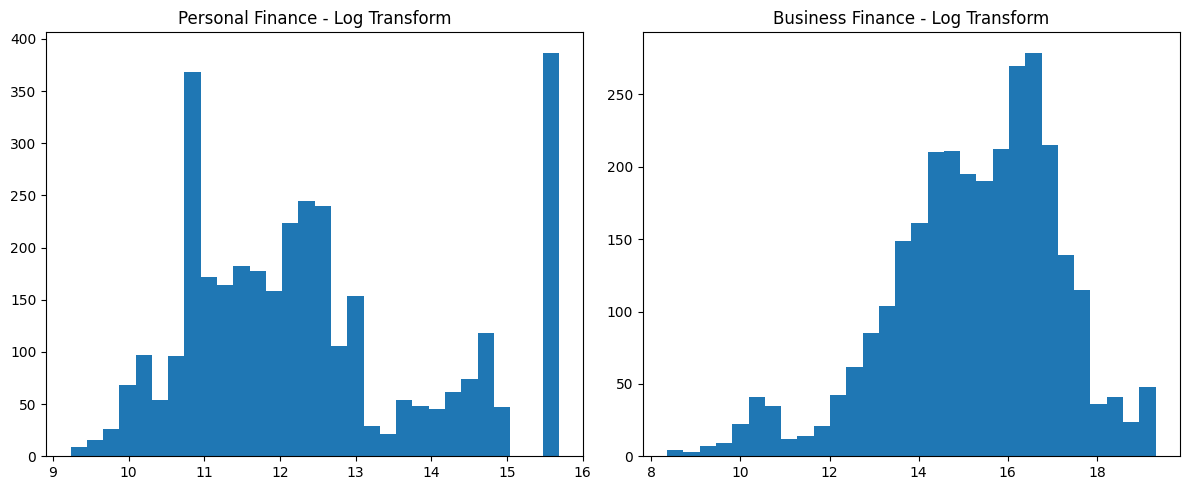

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# personal
axes[0].hist(data_personal['amount_log'], bins=30)
axes[0].set_title('Personal Finance - Log Transform')

# bisnis
axes[1].hist(data_bisnis['amount_log'], bins=30)
axes[1].set_title('Business Finance - Log Transform')

plt.tight_layout()
plt.show()

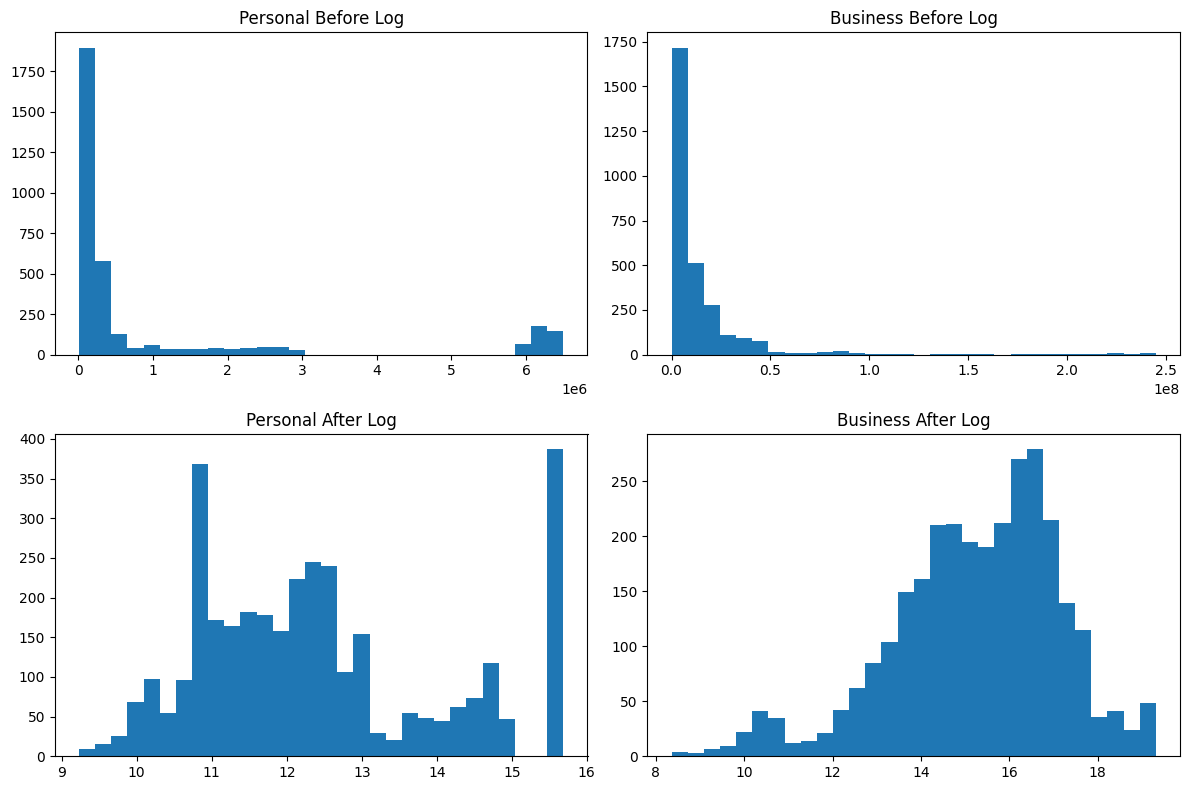

In [54]:
# perbandingan sebelum vs sesudah log transformation
fig, axes = plt.subplots(2, 2, figsize=(12,8))

# sebelum
axes[0,0].hist(data_personal['amount'], bins=30)
axes[0,0].set_title('Personal Before Log')

axes[0,1].hist(data_bisnis['amount'], bins=30)
axes[0,1].set_title('Business Before Log')

# sesudah
axes[1,0].hist(data_personal['amount_log'], bins=30)
axes[1,0].set_title('Personal After Log')

axes[1,1].hist(data_bisnis['amount_log'], bins=30)
axes[1,1].set_title('Business After Log')

plt.tight_layout()
plt.show()

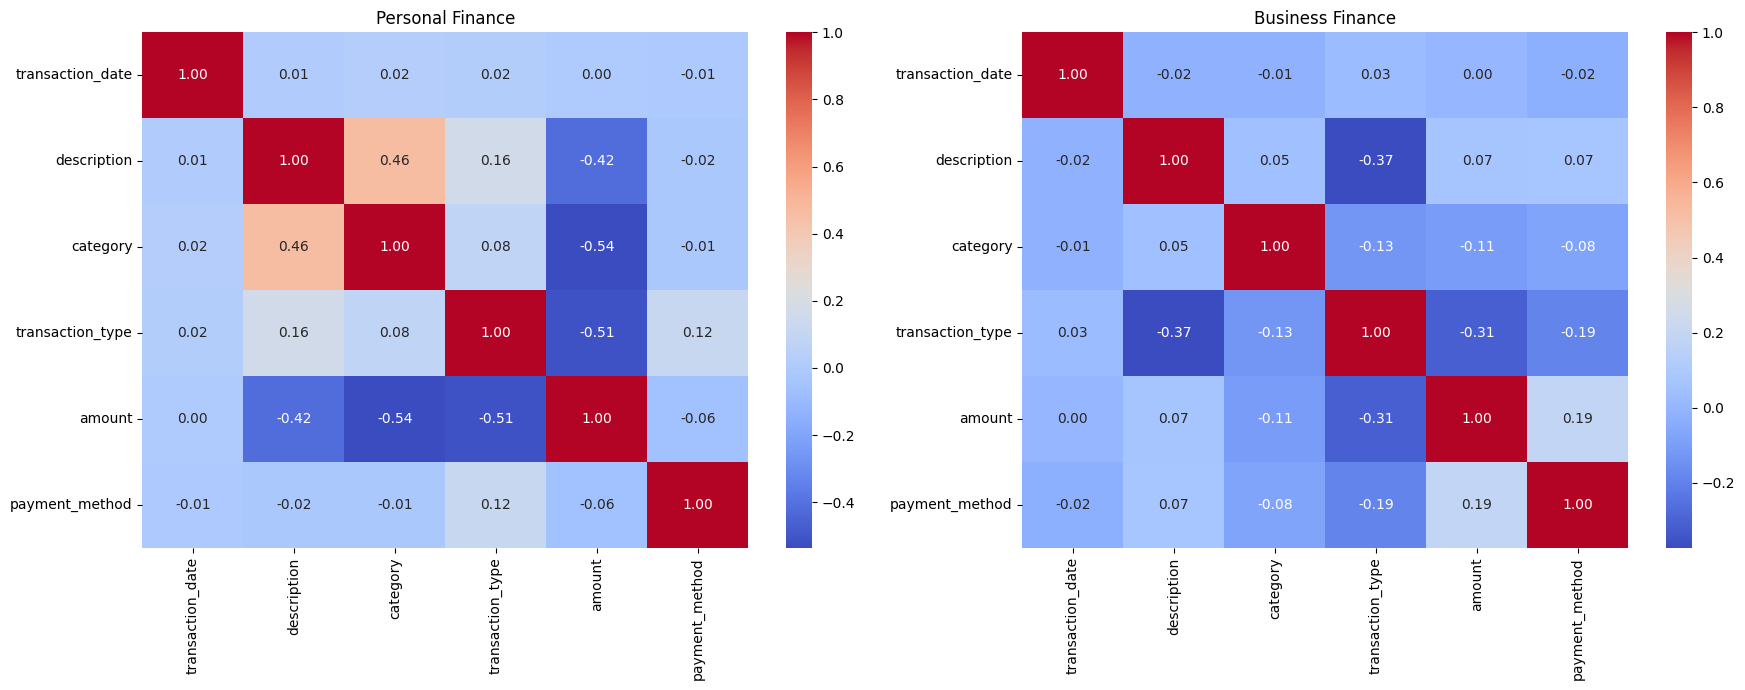

In [81]:
# heatmap korelasi antar variabel
# Personal
personal_corr = data_personal.copy()

personal_corr['transaction_date'] = pd.to_datetime(
    personal_corr['transaction_date']
).astype('int64')

for col in personal_corr.select_dtypes(include='object').columns:
    personal_corr[col] = personal_corr[col].astype('category').cat.codes

# Hapus kolom yang tidak ingin dianalisis
personal_corr = personal_corr.drop(
    columns=['transaction_id', 'amount_log'],
    errors='ignore'
)

# Business
business_corr = data_bisnis.copy()

business_corr['transaction_date'] = pd.to_datetime(
    business_corr['transaction_date']
).astype('int64')

for col in business_corr.select_dtypes(include='object').columns:
    business_corr[col] = business_corr[col].astype('category').cat.codes

# Hapus kolom yang tidak ingin dianalisis
business_corr = business_corr.drop(
    columns=['transaction_id', 'amount_log'],
    errors='ignore'
)

# Korelasi
corr_personal = personal_corr.corr(numeric_only=True)
corr_business = business_corr.corr(numeric_only=True)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(
    corr_personal,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    ax=axes[0]
)
axes[0].set_title('Personal Finance')

sns.heatmap(
    corr_business,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    ax=axes[1]
)
axes[1].set_title('Business Finance')

plt.tight_layout()
plt.show()

mengelompokkan pemasukan dan pendapatan seetiap bulan (df_personal)

In [55]:
# mengubah tanggal menjadi datetime
data_personal['transaction_date'] = pd.to_datetime(data_personal['transaction_date'])
data_personal['month'] = data_personal['transaction_date'].dt.to_period('M')
data_bisnis['transaction_date'] = pd.to_datetime(data_bisnis['transaction_date'])
data_bisnis['month'] = data_bisnis['transaction_date'].dt.to_period('M')

In [56]:
# mengelompokkan pemasukan dan pengeluaran seetiap bulan (df_personal)
monthly_summary = data_personal.groupby(['month', 'transaction_type']).agg({
    'amount': ['sum', 'mean']
}).reset_index()
monthly_summary.head()

month transaction_type       amount              
                                     sum          mean
0  2024-05        Pemasukan   23124068.0  1.778774e+06
1  2024-05      Pengeluaran    3215025.0  1.530964e+05
2  2024-06        Pemasukan  143076513.0  2.384609e+06
3  2024-06      Pengeluaran   15053041.0  1.813619e+05
4  2024-07        Pemasukan  160297686.0  2.081788e+06

In [57]:
# membuat pivot table dan rasio antara pengeluaran dan pemasukan tiap bulan
monthly_summary = data_personal.pivot_table(
    index='month',
    columns='transaction_type',
    values='amount',
    aggfunc='sum',
    fill_value=0
).reset_index()

# tambah kolom rasio
monthly_summary['rasio_pengeluaran (%)'] = (
    monthly_summary['Pengeluaran'] /
    monthly_summary['Pemasukan']
) * 100

monthly_summary

transaction_type,month,Pemasukan,Pengeluaran,rasio_pengeluaran (%)
0,2024-05,23124068.0,3215025.0,13.903371
1,2024-06,143076513.0,15053041.0,10.520973
2,2024-07,160297686.0,13589250.0,8.477509
3,2024-08,126200508.0,25092457.0,19.883008
4,2024-09,100895074.0,13468959.0,13.349471
5,2024-10,104821737.0,9919526.0,9.463234
6,2024-11,162007788.0,10245368.0,6.323997
7,2024-12,95757577.0,16462663.0,17.192021
8,2025-01,145148281.0,8544969.0,5.887062
9,2025-02,103803096.0,9451737.0,9.105448


In [58]:
# rata-rata rasio_pengeluaran selama 2 tahun belakangan
monthly_summary['rasio_pengeluaran (%)'].mean()


np.float64(11.603630554150698)

mengelompokkan pemasukan dan pendapatan seetiap bulan (df_bisnis)

In [59]:
# mengelompokkan pemasukan dan pengeluaran seetiap bulan (df_bisnis)
monthly_summary_bisnis = data_bisnis.groupby(['month', 'transaction_type']).agg({
    'amount': ['sum', 'mean']
}).reset_index()
monthly_summary_bisnis.head()

month transaction_type        amount              
                                      sum          mean
0  2024-05        Pemasukan  1.821931e+08  2.024368e+07
1  2024-05      Pengeluaran  1.258427e+08  6.991262e+06
2  2024-06        Pemasukan  1.397860e+09  2.852776e+07
3  2024-06      Pengeluaran  3.577291e+08  6.749606e+06
4  2024-07        Pemasukan  9.440136e+08  1.888027e+07

In [60]:
# membuat pivot table dan rasio antara pengeluaran dan pemasukan tiap bulan
monthly_summary_bisnis = data_bisnis.pivot_table(
    index='month',
    columns='transaction_type',
    values='amount',
    aggfunc='sum',
    fill_value=0
).reset_index()

# tambah kolom rasio
monthly_summary_bisnis['rasio_pengeluaran (%)'] = (
    monthly_summary_bisnis['Pengeluaran'] /
    monthly_summary_bisnis['Pemasukan']
) * 100

monthly_summary_bisnis

transaction_type,month,Pemasukan,Pengeluaran,rasio_pengeluaran (%)
0,2024-05,1.821931e+08,125842717.0,69.071071
1,2024-06,1.397860e+09,357729140.0,25.591192
2,2024-07,9.440136e+08,402402502.0,42.626769
3,2024-08,1.717418e+09,668059794.5,38.899080
4,2024-09,1.981297e+09,490803798.5,24.771845
5,2024-10,1.849931e+09,955237143.5,51.636376
6,2024-11,1.383250e+09,337560512.0,24.403426
7,2024-12,1.048472e+09,445828125.0,42.521719
8,2025-01,1.999550e+09,449568235.0,22.483476
9,2025-02,1.770113e+09,676327873.0,38.208184


In [61]:
# rata-rata rasio_pengeluaran selama 2 tahun belakangan
monthly_summary_bisnis['rasio_pengeluaran (%)'].mean()


np.float64(36.25787725894133)

In [62]:
# melihat kategori pengeluran yang paling besar tiap bulan (top 3)
# filter hanya pengeluaran
pengeluaran = data_bisnis[
    data_bisnis['transaction_type'] == 'Pengeluaran'
]

# groupby bulan dan kategori pengeluaran
top_pengeluaran = pengeluaran.groupby(
    ['month', 'category']
)['amount'].sum().reset_index()

# urutkan dari terbesar
top_pengeluaran = top_pengeluaran.sort_values(
    ['month', 'amount'],
    ascending=[True, False]
)

# ambil top 3 tiap bulan
top_3_pengeluaran = top_pengeluaran.groupby('month').head(3)
top_3_pengeluaran

,month,category,amount
5,2024-05,Peralatan & Aset,79905862.0
9,2024-05,Utang & Cicilan,16568144.0
1,2024-05,Gaji & Karyawan,8516065.0
19,2024-06,Peralatan & Aset,80235660.0
23,2024-06,Utang & Cicilan,68525847.0
...,...,...,...
287,2026-04,Pembelian Stok,106791060.0
292,2026-04,Utang & Cicilan,94504062.0
305,2026-05,Utang & Cicilan,170229629.0
299,2026-05,Pajak & Perizinan,134439986.0


In [63]:
# count value category pada df top_3_pengeluaran
top_3_pengeluaran['category'].value_counts()

,count
category,
Utang & Cicilan,20
Pajak & Perizinan,18
Peralatan & Aset,16
Pembelian Stok,14
Marketing & Promosi,4
Gaji & Karyawan,3


#Data Visualization

1. Apakah pengguna mampu menjaga pengeluaran pribadi tetap di bawah 80% dari total pemasukan setiap bulan selama dua tahun terakhir?


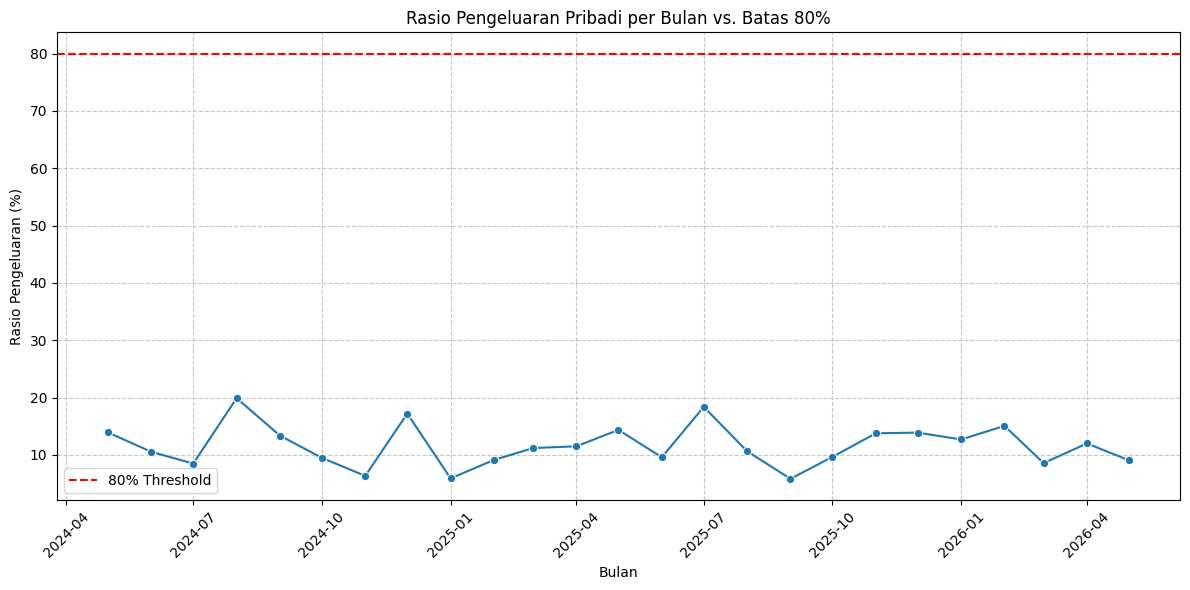

In [64]:
# Convert 'month' Period objects to datetime objects for plotting, if they are not already datetime
if isinstance(monthly_summary['month'].dtype, pd.PeriodDtype):
    monthly_summary['month'] = monthly_summary['month'].dt.to_timestamp()
if isinstance(monthly_summary_bisnis['month'].dtype, pd.PeriodDtype):
    monthly_summary_bisnis['month'] = monthly_summary_bisnis['month'].dt.to_timestamp()

plt.figure(figsize=(12, 6))
sns.lineplot(x='month', y='rasio_pengeluaran (%)', data=monthly_summary, marker='o')
plt.axhline(y=80, color='r', linestyle='--', label='80% Threshold')
plt.title('Rasio Pengeluaran Pribadi per Bulan vs. Batas 80%')
plt.xlabel('Bulan')
plt.ylabel('Rasio Pengeluaran (%)')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

print('\n')

2. Bagaimana kondisi arus kas bisnis selama dua tahun terakhir, dan kategori biaya bisnis apa yang paling besar mengurangi keuntungan bulanan?

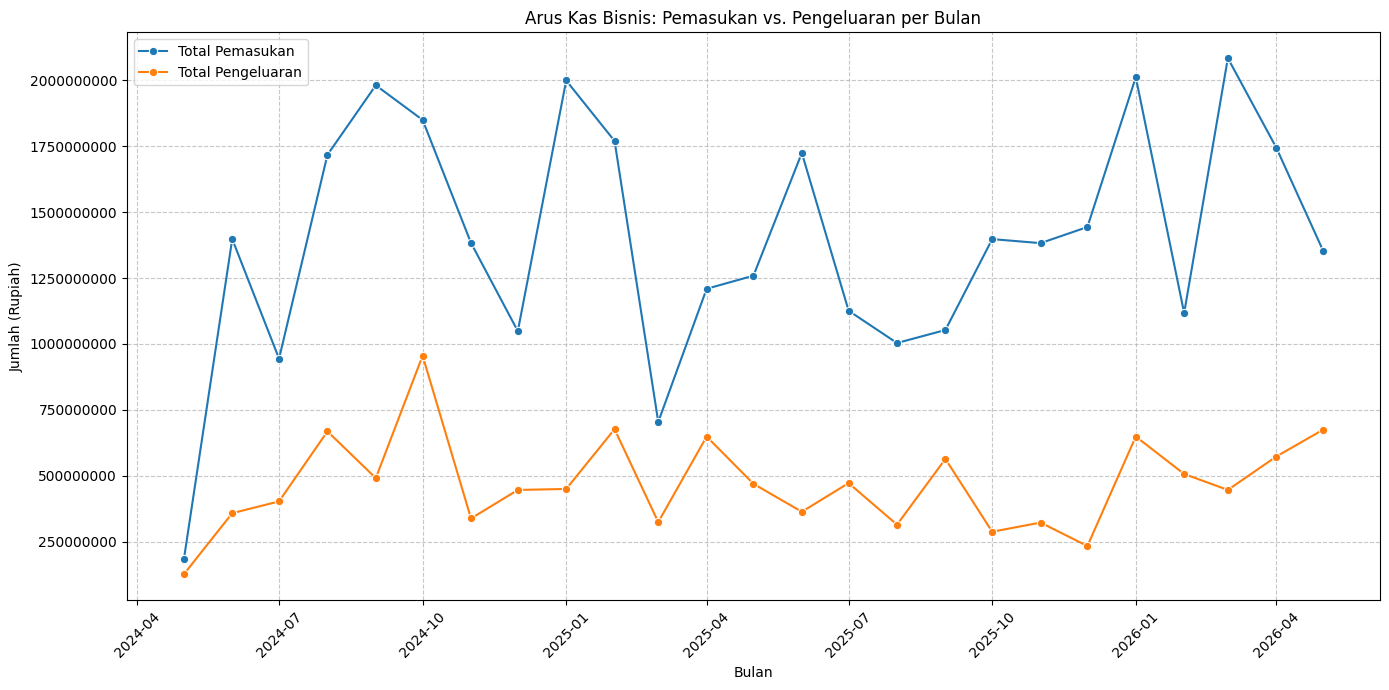

In [65]:
plt.figure(figsize=(14, 7))
sns.lineplot(x='month', y='Pemasukan', data=monthly_summary_bisnis, label='Total Pemasukan', marker='o')
sns.lineplot(x='month', y='Pengeluaran', data=monthly_summary_bisnis, label='Total Pengeluaran', marker='o')
plt.title('Arus Kas Bisnis: Pemasukan vs. Pengeluaran per Bulan')
plt.xlabel('Bulan')
plt.ylabel('Jumlah (Rupiah)')
plt.ticklabel_format(style='plain', axis='y')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

print('\n')

/tmp/ipykernel_2811/4216439385.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_3_pengeluaran['month'] = top_3_pengeluaran['month'].dt.to_timestamp()


<Figure size 1500x800 with 0 Axes>

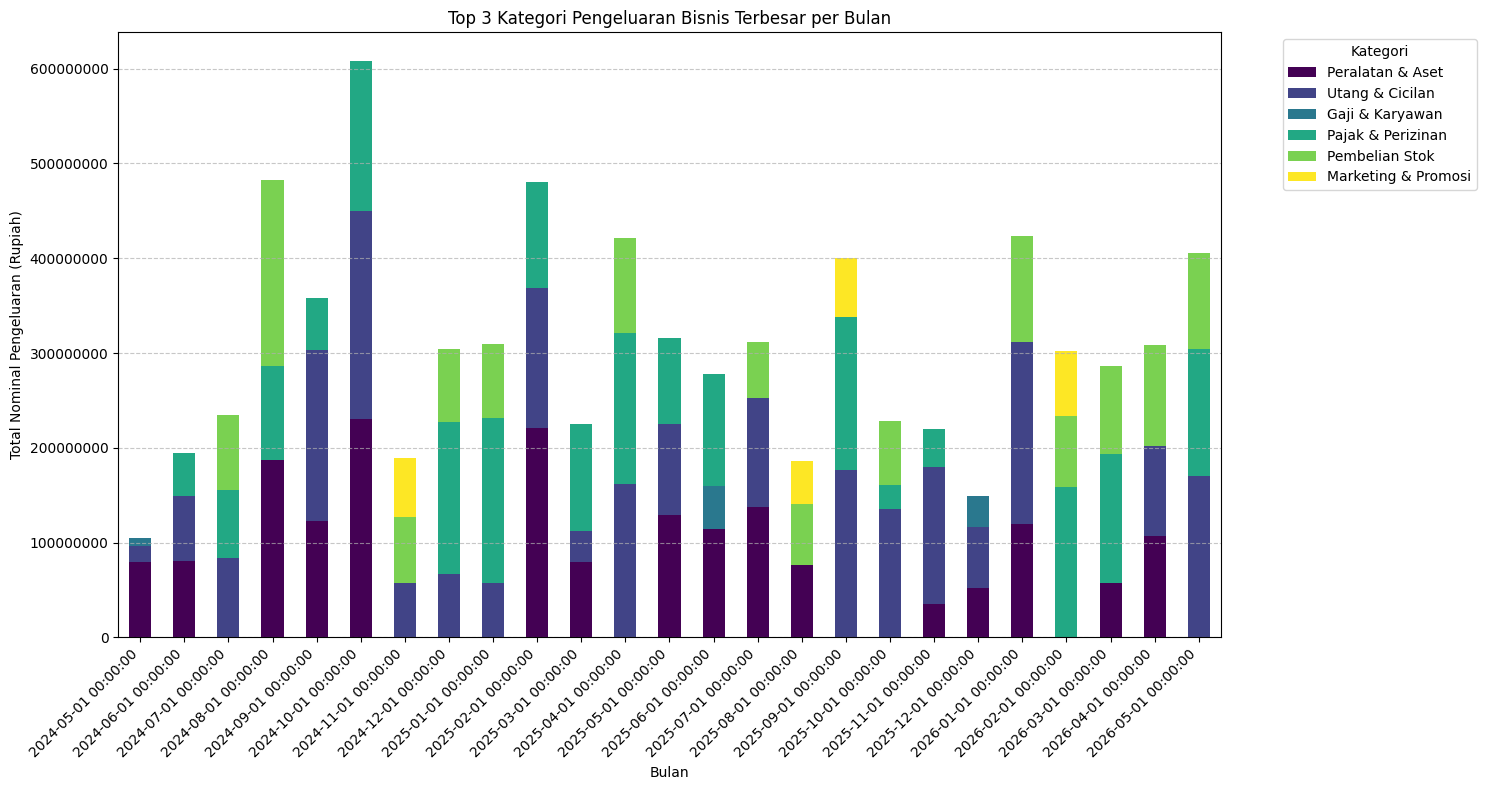

In [66]:
# Convert 'month' Period objects to datetime objects for plotting
if isinstance(top_3_pengeluaran['month'].dtype, pd.PeriodDtype):
    top_3_pengeluaran['month'] = top_3_pengeluaran['month'].dt.to_timestamp()

# Pivot the table to get categories as columns for stacking
pivoted_top_3_pengeluaran = top_3_pengeluaran.pivot_table(
    index='month',
    columns='category',
    values='amount',
    fill_value=0
)

# Sort the columns to ensure consistent stacking order (optional, but good practice)
pivoted_top_3_pengeluaran = pivoted_top_3_pengeluaran.reindex(
    columns=top_3_pengeluaran['category'].unique()
)

plt.figure(figsize=(15, 8))
ax = pivoted_top_3_pengeluaran.plot(kind='bar', stacked=True, figsize=(15, 8), cmap='viridis')

plt.title('Top 3 Kategori Pengeluaran Bisnis Terbesar per Bulan')
plt.xlabel('Bulan')
plt.ylabel('Total Nominal Pengeluaran (Rupiah)')
plt.ticklabel_format(style='plain', axis='y') # Avoid scientific notation on y-axis
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Kategori', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

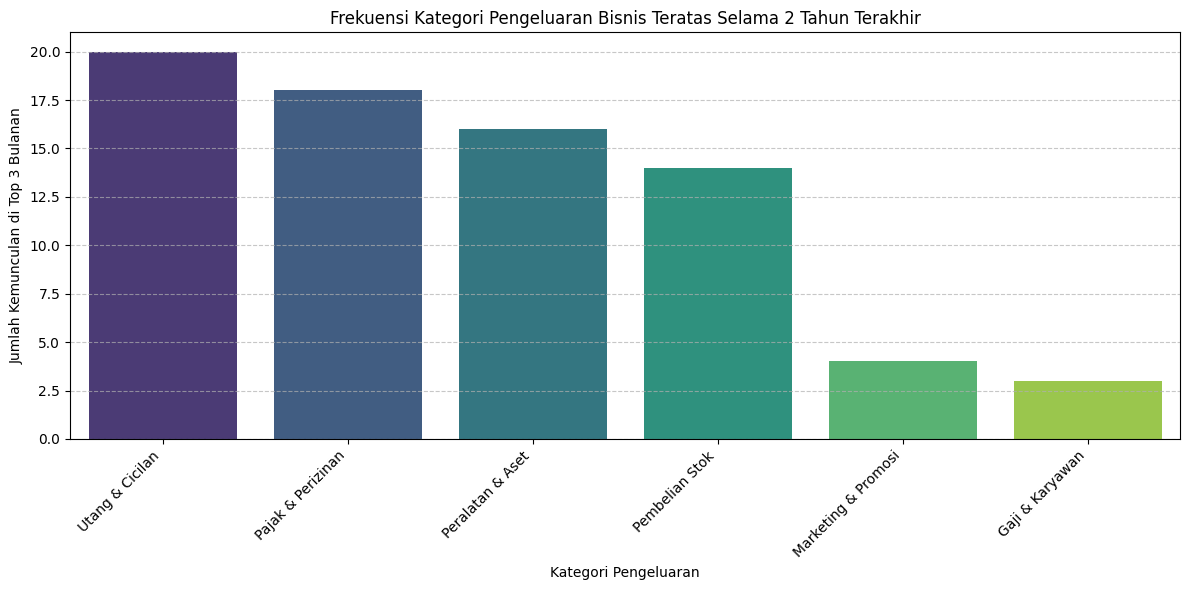

In [67]:
plt.figure(figsize=(12, 6))
sns.barplot(x=top_3_pengeluaran['category'].value_counts().index,
            y=top_3_pengeluaran['category'].value_counts().values,
            hue=top_3_pengeluaran['category'].value_counts().index, legend=False,
            palette='viridis')
plt.title('Frekuensi Kategori Pengeluaran Bisnis Teratas Selama 2 Tahun Terakhir')
plt.xlabel('Kategori Pengeluaran')
plt.ylabel('Jumlah Kemunculan di Top 3 Bulanan')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Insight:

dari (df_personal)
1. Selama 2 tahun terakhir pengguna mampu menjaga pengeluaran pribadi tetap di bawah 80% dari total pemasukan setiap bulan kecuali pada Bulan Mei 2024. Pada Mei 2024, rasio pengeluaran pribadi pengguna mencapai 123% dari batas yang telah ditetapkan.
2. Rata-rata pengeluaran pengguna selama 2 tahun terakhir yakni 39.9% dari total pemasukan pengguna.

dari (df_bisnis)
1. Selama 2 tahun terakhir, kondisi arus kas bisnis tergolong sehat, dengan rasio rata-rata pengeluaran sebesar 36.7% dari total pendapatan.
2. Kategori pengeluaran bisnis yang memiliki nominal paling besar cukup beragam tiap bulan. Namun selama 2 tahun terakhir kategori (Gaji & Karyawan), (Peralatan & Aset), dan (Operasional Kantro) yang paling sering muncul dan memiliki nominal besar

# Classification

In [68]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

In [69]:
data = pd.read_csv("/content/fintrack_business_clean_dataset.csv")
data.head(10)

,transaction_id,transaction_date,description,category,transaction_type,amount,payment_method
0,1,2024-05-27,Pendapatan marketplace,Penjualan,Pemasukan,676749.0,QRIS
1,2,2024-05-15,Pendapatan proyek,Penjualan,Pemasukan,22241448.0,Tunai
2,3,2024-05-01,Investasi investor,Modal & Investasi,Pemasukan,85947193.0,Transfer Bank
3,3001,2024-05-05,Penjualan produk,Penjualan,Pemasukan,1278397.0,Tunai
4,5,2024-05-06,Pendapatan proyek,Penjualan,Pemasukan,10420797.0,Lainnya
5,6,2024-05-10,PPh,Pajak & Perizinan,Pengeluaran,5171400.0,Transfer Bank
6,7,2024-05-13,Pembelian printer,Peralatan & Aset,Pengeluaran,10661767.0,Transfer Bank
7,8,2024-05-22,Pembelian laptop,Peralatan & Aset,Pengeluaran,39964259.0,Transfer Bank
8,9,2024-05-07,Tools desain,Software & Langganan,Pengeluaran,222292.0,Transfer Bank
9,10,2024-05-06,Ongkos kirim,Transportasi & Logistik,Pengeluaran,255764.0,E-Wallet


In [70]:
# drop variabel transaction_id dan transaction_date
dataa = data.drop(columns=['transaction_id','transaction_date'])
dataa

,description,category,transaction_type,amount,payment_method
0,Pendapatan marketplace,Penjualan,Pemasukan,676749.0,QRIS
1,Pendapatan proyek,Penjualan,Pemasukan,22241448.0,Tunai
2,Investasi investor,Modal & Investasi,Pemasukan,85947193.0,Transfer Bank
3,Penjualan produk,Penjualan,Pemasukan,1278397.0,Tunai
4,Pendapatan proyek,Penjualan,Pemasukan,10420797.0,Lainnya
...,...,...,...,...,...
2951,Biaya ekspedisi,Piutang,Pengeluaran,1787001.0,Kartu Debit
2952,THR,Gaji & Karyawan,Pengeluaran,7391321.0,Transfer Bank
2953,Pendapatan grosir,Penjualan,Pemasukan,29146152.0,Lainnya
2954,Biaya tak terduga,Penjualan,Pengeluaran,4319304.0,Transfer Bank


In [71]:
## Buat instance LabelEncoder
label_encoder = LabelEncoder()

## List kolom kategorikal yang perlu di-encode
categorical_columns = ['description','transaction_type', 'payment_method']

## Encode kolom kategorikal
for column in categorical_columns:
    dataa[column] = label_encoder.fit_transform(dataa[column])

dataa.head(15)

,description,category,transaction_type,amount,payment_method
0,61,Penjualan,0,676749.0,5
1,62,Penjualan,0,22241448.0,7
2,33,Modal & Investasi,0,85947193.0,6
3,66,Penjualan,0,1278397.0,7
4,62,Penjualan,0,10420797.0,3
5,45,Pajak & Perizinan,1,5171400.0,6
6,59,Peralatan & Aset,1,10661767.0,6
7,56,Peralatan & Aset,1,39964259.0,6
8,79,Software & Langganan,1,222292.0,6
9,43,Transportasi & Logistik,1,255764.0,0


In [72]:
# Buat instance MinMaxScaler
scaler = MinMaxScaler()

# Normalisasi semua kolom numerik
numeric_columns = dataa.select_dtypes(include=['int64', 'float64']).columns
dataa[numeric_columns] = scaler.fit_transform(dataa[numeric_columns])

# Pisahkan fitur (X) dan target (y)
X = dataa.drop(columns=['category'])
y = dataa['category']

# Split data menjadi set pelatihan dan set uji
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

# Tampilkan bentuk set pelatihan dan set uji untuk memastikan split
print(f"Training set shape: X_train={X_train.shape}, y_train={y_train.shape}")
print(f"Test set shape: X_test={X_test.shape}, y_test={y_test.shape}")

Training set shape: X_train=(2364, 4), y_train=(2364,)
Test set shape: X_test=(592, 4), y_test=(592,)


In [73]:
# Model Training
dt = DecisionTreeClassifier().fit(X_train, y_train)
rf = RandomForestClassifier().fit(X_train, y_train)

## Decision Tree

In [74]:
# DT

## Evaluasi model train
y_pred_dt = dt.predict(X_train)
cm_dt = confusion_matrix(y_train, y_pred_dt)
print(cm_dt, '\n')

acc_dt_train = accuracy_score(y_train, y_pred_dt)
print("Accuracy:", acc_dt_train)

prec_dt_train = precision_score(
    y_train,
    y_pred_dt,
    average='weighted'
)
print("Precision:", prec_dt_train)

rec_dt_train = recall_score(y_train, y_pred_dt, average='weighted')
print("Recall (train):", rec_dt_train)

[[141   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0 125   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0 116   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0 103   0   0   0   0   0   0   0   0   0   0]
 [  0   1   0   0 320   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0 130   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0 110   0   0   0   0   0   0   0]
 [  0   0   0   0   1   0   0 133   0   0   0   0   0   0]
 [  2   0   1   0   0   0   0   2 347   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0 114   0   0   0   0]
 [  0   1   0   0   0   0   0   0   0   0 339   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0 125   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0 123   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0 130]] 

Accuracy: 0.9966159052453468
Precision: 0.9966509432801717
Recall (train): 0.9966159052453468


In [75]:
# DT
## Evaluasi model test
y_pred_dt1 = dt.predict(X_test)
cm_dt1 = confusion_matrix(y_test, y_pred_dt1)
print(cm_dt1, '\n')

acc_dt_test = accuracy_score(y_test, y_pred_dt1)
print("Accuracy (test):", acc_dt_test)

prec_dt_test = precision_score(y_test, y_pred_dt1, average='weighted')
print("Precision (test):", prec_dt_test)

rec_dt_test = recall_score(y_test, y_pred_dt1, average='weighted')
print("Recall (test):", rec_dt_test)

[[37  0  0  0  0  0  0  0  0  0  1  0  0  0]
 [ 1 31  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0 25  1  0  0  0  0  2  0  0  0  0  0]
 [ 0  0  0 26  2  0  0  0  0  0  1  0  0  0]
 [ 0  0  1  4 76  0  3  1  0  0  0  0  0  0]
 [ 0  0  0  0  0 21  1  0  1  0  0  0  0  0]
 [ 0  0  0  0  0  1 29  0  1  0  0  0  0  0]
 [ 0  0  0  0  0  0  0 32  1  0  0  0  0  0]
 [ 2  0  0  0  0  2  1  0 78  1  0  0  2  1]
 [ 0  0  0  0  0  0  0  0  1 25  0  0  0  0]
 [ 0  0  0  0  0  2  0  0  0  3 79  0  0  1]
 [ 0  0  0  0  1  0  0  0  1  0  0 35  0  0]
 [ 0  0  2  0  0  0  0  0  1  0  2  0 17  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  4  0 32]] 

Accuracy (test): 0.9172297297297297
Precision (test): 0.9193562636309002
Recall (test): 0.9172297297297297


## Random Forest

In [76]:
# RF

## Evaluasi model train
y_pred_rf = rf.predict(X_train)
cm_rf = confusion_matrix(y_train, y_pred_rf)
print(cm_rf, '\n')

acc_rf_train = accuracy_score(y_train, y_pred_rf)
print("Accuracy:", acc_rf_train)

prec_rf_train = precision_score(
    y_train,
    y_pred_rf,
    average='weighted'
)
print("Precision:", prec_rf_train)

rec_rf_train = recall_score(y_train, y_pred_rf, average='weighted')
print("Recall (train):", rec_rf_train)

[[139   0   0   0   0   0   0   0   2   0   0   0   0   0]
 [  0 125   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0 116   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0 103   0   0   0   0   0   0   0   0   0   0]
 [  0   1   0   0 320   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0 130   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0 110   0   0   0   0   0   0   0]
 [  0   0   0   0   1   0   0 131   2   0   0   0   0   0]
 [  0   0   1   0   0   0   0   0 351   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0 114   0   0   0   0]
 [  0   1   0   0   0   0   0   0   0   0 339   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0 125   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0 123   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0 130]] 

Accuracy: 0.9966159052453468
Precision: 0.9966471429308125
Recall (train): 0.9966159052453468


In [77]:
# RF
## Evaluasi model test
y_pred_rf1 = rf.predict(X_test)
cm_rf1 = confusion_matrix(y_test, y_pred_rf1)
print(cm_rf1, '\n')

acc_rf_test = accuracy_score(y_test, y_pred_rf1)
print("Accuracy (test):", acc_rf_test)

prec_rf_test = precision_score(y_test, y_pred_rf1, average='weighted')
print("Precision (test):", prec_rf_test)

rec_rf_test = recall_score(y_test, y_pred_rf1, average='weighted')
print("Recall (test):", rec_rf_test)

[[37  0  0  0  0  0  0  0  0  0  1  0  0  0]
 [ 0 31  0  0  0  0  0  0  0  0  0  0  0  1]
 [ 0  0 25  1  0  0  0  0  1  0  0  1  0  0]
 [ 0  0  0 23  2  3  0  0  0  0  0  1  0  0]
 [ 0  0  1  4 75  0  3  2  0  0  0  0  0  0]
 [ 0  0  0  0  0 22  0  0  1  0  0  0  0  0]
 [ 0  0  0  0  0  1 27  0  1  0  0  0  2  0]
 [ 0  0  0  0  0  0  0 32  1  0  0  0  0  0]
 [ 1  0  0  0  0  1  1  0 81  1  0  0  1  1]
 [ 0  0  0  0  0  0  0  1  0 25  0  0  0  0]
 [ 0  1  0  0  0  1  0  0  0  1 81  0  0  1]
 [ 0  0  0  0  0  2  0  0  1  0  0 34  0  0]
 [ 0  0  1  0  0  0  0  0  1  0  2  1 17  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  4  0 32]] 

Accuracy (test): 0.9155405405405406
Precision (test): 0.9187723477357626
Recall (test): 0.9155405405405406
